Initial Hypothesis:
['Ø', 'Ø', 'Ø', 'Ø', 'Ø', 'Ø']

Positive Example: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
Hypothesis: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']

Positive Example: ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same']
Hypothesis: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']

Positive Example: ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change']
Hypothesis: ['Sunny', 'Warm', '?', 'Strong', '?', '?']

Final Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']
Hypothesis History
H0 = ['Ø', 'Ø', 'Ø', 'Ø', 'Ø', 'Ø']
H1 = ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
H2 = ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
H3 = ['Sunny', 'Warm', '?', 'Strong', '?', '?']

Final Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


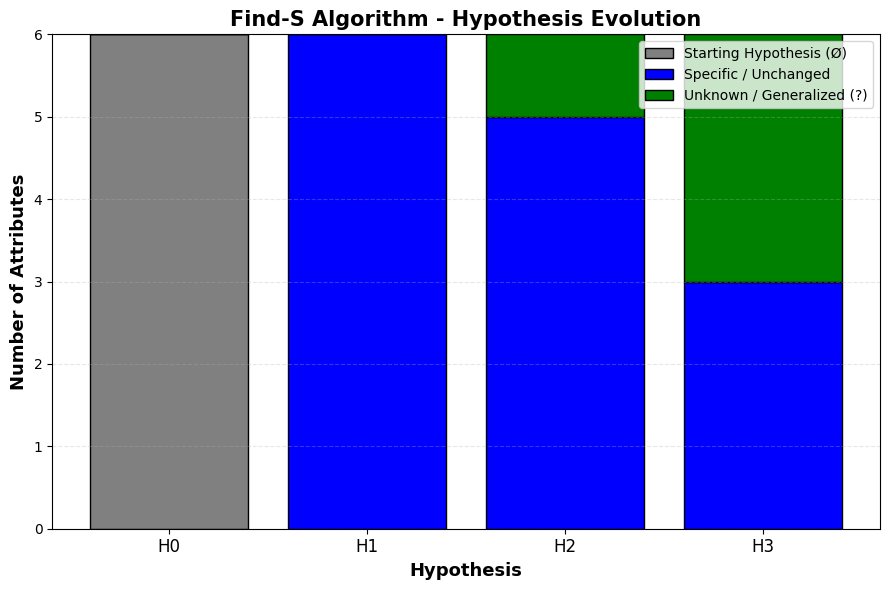

In [1]:
# -*- coding: utf-8 -*-
"""ML lab2 prgm1.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1bBO-YN4E-f_hwyNKiA-ivia6F2fr7JAM
"""

# Find-S Algorithm

# Dataset
data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', '+'],
    ['Sunny', 'Warm', 'High',   'Strong', 'Warm', 'Same', '+'],
    ['Rainy', 'Cold', 'High',   'Strong', 'Warm', 'Change', '-'],
    ['Sunny', 'Warm', 'High',   'Strong', 'Cool', 'Change', '+']
]

# Attribute names
attributes = [
    'Outlook',
    'Temperature',
    'Humidity',
    'Wind',
    'Water',
    'Forecast'
]

# Target column is the last column
target_index = 6

# Initial hypothesis
hypothesis = ['Ø'] * len(attributes)

print("Initial Hypothesis:")
print(hypothesis)

# Process each example
for i, example in enumerate(data):

    # Consider only positive examples
    if example[target_index] == '+':

        print("\nPositive Example:", example[:-1])

        # First positive example
        if hypothesis == ['Ø'] * len(attributes):
            hypothesis = example[:-1]

        else:
            # Compare with current hypothesis
            for j in range(len(attributes)):

                if hypothesis[j] != example[j]:
                    hypothesis[j] = '?'

        print("Hypothesis:", hypothesis)


print("\nFinal Hypothesis:")
print(hypothesis)

import matplotlib.pyplot as plt
import numpy as np


data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', '+'],
    ['Sunny', 'Warm', 'High',   'Strong', 'Warm', 'Same', '+'],
    ['Rainy', 'Cold', 'High',   'Strong', 'Warm', 'Change', '-'],
    ['Sunny', 'Warm', 'High',   'Strong', 'Cool', 'Change', '+']
]

attributes = [
    'Outlook',
    'Temperature',
    'Humidity',
    'Wind',
    'Water',
    'Forecast'
]

target_index = 6


# =====================================================
# FIND-S ALGORITHM
# =====================================================

hypothesis = ['Ø'] * len(attributes)

history = []

# Initial hypothesis H0
history.append(hypothesis.copy())

# Process positive examples
for example in data:

    if example[target_index] == '+':

        # First positive example
        if hypothesis == ['Ø'] * len(attributes):
            hypothesis = example[:-1]

        else:
            # Compare attributes
            for i in range(len(attributes)):
                if hypothesis[i] != example[i]:
                    hypothesis[i] = '?'

        # Save hypothesis
        history.append(hypothesis.copy())



print("Hypothesis History")
print("=" * 50)

for i, h in enumerate(history):
    print(f"H{i} = {h}")

print("\nFinal Hypothesis:")
print(hypothesis)



gray_count = []
blue_count = []
green_count = []

for h in history:

    # Starting hypothesis
    gray = h.count('Ø')

    # Unknown/generalized
    green = h.count('?')

    # Specific values
    blue = len(h) - gray - green

    gray_count.append(gray)
    blue_count.append(blue)
    green_count.append(green)


hypotheses = [f'H{i}' for i in range(len(history))]

x = np.arange(len(hypotheses))

plt.figure(figsize=(9, 6))

plt.bar(
    x,
    gray_count,
    color='gray',
    edgecolor='black',
    label='Starting Hypothesis (Ø)'
)

plt.bar(
    x,
    blue_count,
    bottom=gray_count,
    color='blue',
    edgecolor='black',
    label='Specific / Unchanged'
)

plt.bar(
    x,
    green_count,
    bottom=np.array(gray_count) + np.array(blue_count),
    color='green',
    edgecolor='black',
    label='Unknown / Generalized (?)'
)

plt.xticks(
    x,
    hypotheses,
    fontsize=12
)

plt.xlabel(
    'Hypothesis',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Number of Attributes',
    fontsize=13,
    fontweight='bold'
)

plt.title(
    'Find-S Algorithm - Hypothesis Evolution',
    fontsize=15,
    fontweight='bold'
)

# Y-axis: 1, 2, 3, 4, 5, 6
plt.yticks(
    range(0, len(attributes) + 1)
)

plt.ylim(0, len(attributes))

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()